<a href="https://colab.research.google.com/github/5599961370/Bureaucracy_AI/blob/main/Scalable_Predictive_Maintenance_Using_Machine_Learning_on_NASA_CMAPSS_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving train_FD001.txt to train_FD001 (1).txt
   unit  cycle     op1     op2    op3      s1      s2       s3       s4  \
0     1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1     1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2     1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3     1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4     1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23

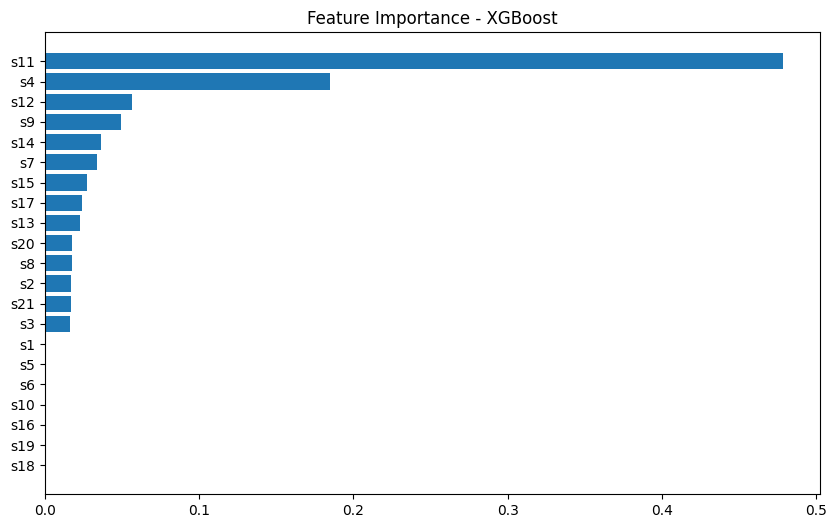

In [1]:
# =====================================================
# Predictive Maintenance - NASA CMAPSS FD001 (XGBoost)
# =====================================================

# ================================
# 1. Install & Import
# ================================
!pip install -q pandas scikit-learn xgboost matplotlib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ================================
# 2. Load Dataset
# ================================
from google.colab import files
uploaded = files.upload()

filename = "train_FD001.txt"

columns = [
    'unit', 'cycle',
    'op1', 'op2', 'op3',
    's1','s2','s3','s4','s5','s6','s7','s8','s9','s10',
    's11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21'
]

df = pd.read_csv(filename, sep=r"\s+", header=None, names=columns)

print(df.head())

# ================================
# 3. Compute RUL (Remaining Useful Life)
# ================================
max_cycle = df.groupby("unit")["cycle"].max().reset_index()
max_cycle.columns = ["unit", "max_cycle"]

df = df.merge(max_cycle, on="unit")
df["RUL"] = df["max_cycle"] - df["cycle"]

# ================================
# 4. Binary Classification Label
# ================================
# Failure if RUL <= 30
df["failure"] = (df["RUL"] <= 30).astype(int)

print(df["failure"].value_counts())

# ================================
# 5. Feature Selection
# ================================
sensor_cols = [f"s{i}" for i in range(1, 22)]

X = df[sensor_cols]
y = df["failure"]

# ================================
# 6. Train / Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ================================
# 7. Train XGBoost Model
# ================================
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    eval_metric="auc",
    random_state=42
)

model.fit(X_train, y_train)

# ================================
# 8. Evaluation
# ================================
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n AUC Score: {auc:.4f}")

y_pred = (y_pred_proba > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ================================
# 9. Feature Importance
# ================================
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": sensor_cols,
    "importance": importance
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.show()


Number of training units: 80
Number of testing units: 20
Shared units: 0
✓ No unit overlap between Train and Test

Training class distribution:
failure
0    14081
1     2480
Name: count, dtype: int64

Testing class distribution:
failure
0    3450
1     620
Name: count, dtype: int64

scale_pos_weight: 5.677822580645161

🔥 Unit-wise AUC Score: 0.9905

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3450
           1       0.79      0.94      0.86       620

    accuracy                           0.95      4070
   macro avg       0.89      0.95      0.91      4070
weighted avg       0.96      0.95      0.95      4070


MODEL COMPARISON
Random Stratified Split AUC : 0.9901
Unit-wise Split AUC         : 0.9905

Top 10 Important Sensors:
feature  importance
    s11    0.449547
     s4    0.201356
     s9    0.052011
    s12    0.051694
    s14    0.039386
     s7    0.035098
    s15    0.027633
    s17    0.025578

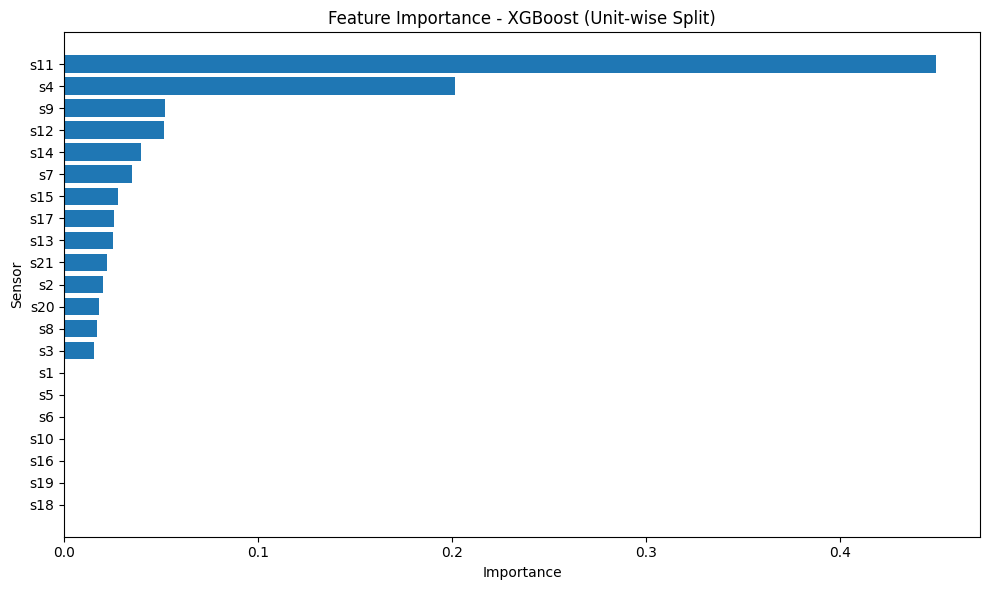

In [2]:
# =====================================================
# Experiment 2 - Unit-wise Train/Test Split
# NASA CMAPSS FD001 + XGBoost
# =====================================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report

# =====================================================
# 1. Features and Target
# =====================================================

sensor_cols = [f"s{i}" for i in range(1, 22)]

X = df[sensor_cols]
y = df["failure"]

# Unit IDs used as groups
groups = df["unit"]

# =====================================================
# 2. Split by Engine / Unit
# =====================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train_group = X.iloc[train_idx]
X_test_group = X.iloc[test_idx]

y_train_group = y.iloc[train_idx]
y_test_group = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

# =====================================================
# 3. Verify No Unit Leakage
# =====================================================

train_units = set(groups_train.unique())
test_units = set(groups_test.unique())

overlap = train_units.intersection(test_units)

print("Number of training units:", len(train_units))
print("Number of testing units:", len(test_units))
print("Shared units:", len(overlap))

assert len(overlap) == 0, "ERROR: Unit leakage detected!"

print("✓ No unit overlap between Train and Test")

# =====================================================
# 4. Check Class Distribution
# =====================================================

print("\nTraining class distribution:")
print(y_train_group.value_counts())

print("\nTesting class distribution:")
print(y_test_group.value_counts())

# =====================================================
# 5. Calculate Class Weight
# =====================================================

negative = (y_train_group == 0).sum()
positive = (y_train_group == 1).sum()

scale_pos_weight = negative / positive

print("\nscale_pos_weight:", scale_pos_weight)

# =====================================================
# 6. Train XGBoost
# =====================================================

group_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

group_model.fit(
    X_train_group,
    y_train_group
)

# =====================================================
# 7. Probability Prediction
# =====================================================

y_pred_proba_group = group_model.predict_proba(
    X_test_group
)[:, 1]

# =====================================================
# 8. ROC-AUC
# =====================================================

auc_group = roc_auc_score(
    y_test_group,
    y_pred_proba_group
)

print("\n🔥 Unit-wise AUC Score:", round(auc_group, 4))

# =====================================================
# 9. Classification Report
# =====================================================

y_pred_group = (
    y_pred_proba_group > 0.5
).astype(int)

print("\nClassification Report:")
print(
    classification_report(
        y_test_group,
        y_pred_group
    )
)

# =====================================================
# 10. Compare with Baseline
# =====================================================

print("\n" + "=" * 55)
print("MODEL COMPARISON")
print("=" * 55)

print(f"Random Stratified Split AUC : 0.9901")
print(f"Unit-wise Split AUC         : {auc_group:.4f}")

print("=" * 55)

# =====================================================
# 11. Feature Importance
# =====================================================

importance_group = group_model.feature_importances_

feat_imp_group = pd.DataFrame({
    "feature": sensor_cols,
    "importance": importance_group
}).sort_values(
    by="importance",
    ascending=False
)

print("\nTop 10 Important Sensors:")
print(
    feat_imp_group.head(10).to_string(index=False)
)

# =====================================================
# 12. Feature Importance Plot
# =====================================================

plt.figure(figsize=(10, 6))

plt.barh(
    feat_imp_group["feature"],
    feat_imp_group["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Feature Importance - XGBoost (Unit-wise Split)"
)

plt.xlabel("Importance")
plt.ylabel("Sensor")

plt.tight_layout()
plt.show()